# 🌾 Notebook 1: EDA and Data Preparation
**Project:** EcoCrop Tunisia — Crop Yield Prediction

**Authors:** Ferdaws Saidi & Aya Gharsalli

**Objective:** Perform a thorough exploratory data analysis (EDA) on the EcoCrop dataset. Uncover distributions, correlations, outliers, and seasonal patterns. Prepare clean, engineered features ready for modeling in Notebook 2.

---
**Dataset Features:**
- `precipitation` — Monthly rainfall (mm)
- `hc_air_temperature` — Air temperature (°C)
- `hc_relative_humidity` — Relative humidity (%)
- `solar_radiation` — Solar radiation (W/m²)
- `wind_speed_sonic` — Wind speed (m/s)
- `Governorate` — Tunisian administrative region
- `Year` — Year of observation (2016–2024)
- **Crop yield targets:** Cereales, Maraichage, Legumineuses, Fourrages, Arboriculture, Olives, Cultures industrielles (all in Tonnes)

## 📦 1. Imports & Configuration

In [ ]:
# --- Imports & Global Configuration ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')
PALETTE = sns.color_palette('Set2')

CROP_COLS = [
    'Cereales (T)', 'Maraichage (T)', 'Legumineuses (T)',
    'Fourrages (T)', 'Arboriculture (T)', 'Olives (T)',
    'Cultures industrielles (T)'
]
WEATHER_COLS = [
    'precipitation', 'hc_air_temperature',
    'hc_relative_humidity', 'solar_radiation', 'wind_speed_sonic'
]

print('✅ Libraries loaded successfully.')

✅ Libraries loaded successfully.


## 📂 2. Load & First Look

In [ ]:
# --- Load Dataset ---
df = pd.read_csv('ecocrop_cleaned_data (1).csv')

print(f'📐 Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'📅 Years covered: {df["Year"].min()} → {df["Year"].max()}')
print(f'🗺️  Governorates: {df["Governorate"].nunique()} unique regions')
print('\n--- Column types ---')
print(df.dtypes)
print('\n--- First 5 rows ---')
display(df.head())

📐 Shape: 1,479 rows × 15 columns
📅 Years covered: 2016 → 2024
🗺️  Governorates: 8 unique regions

--- Column types ---
Governorate                    object
Date                           object
precipitation                 float64
hc_air_temperature            float64
hc_relative_humidity          float64
solar_radiation               float64
wind_speed_sonic              float64
Cereales (T)                  float64
Maraichage (T)                float64
Legumineuses (T)              float64
Fourrages (T)                 float64
Arboriculture (T)             float64
Olives (T)                    float64
Cultures industrielles (T)    float64
Year                            int64
dtype: object

--- First 5 rows ---


,Governorate,Date,precipitation,hc_air_temperature,hc_relative_humidity,solar_radiation,wind_speed_sonic,Cereales (T),Maraichage (T),Legumineuses (T),Fourrages (T),Arboriculture (T),Olives (T),Cultures industrielles (T),Year
0,BEJA,2025-09-26,0.0,16.47519,66.286453,55.833333,0.8,690000.0,204312.0,48906.0,606414.0,98400.0,87000.0,0.0,2018
1,BEJA,2025-09-26,0.0,16.47519,66.286453,55.833333,0.8,820000.0,289366.0,54340.0,241400.0,110600.0,65000.0,0.0,2019
2,BEJA,2025-09-26,0.0,16.47519,66.286453,55.833333,0.8,580000.0,375200.0,40000.0,70000.0,126200.0,138000.0,0.0,2020
3,BEJA,2025-09-26,0.0,16.47519,66.286453,55.833333,0.8,740000.0,354000.0,51000.0,686800.0,152000.0,65000.0,0.0,2021
4,BEJA,2025-09-26,0.0,16.47519,66.286453,55.833333,0.8,800000.0,280000.0,52280.0,768800.0,130400.0,80000.0,0.0,2022


## 📊 3. Descriptive Statistics

In [ ]:
# --- Descriptive Statistics (Weather vs Crop separated) ---
print('=== WEATHER VARIABLES ===')
display(df[WEATHER_COLS].describe().round(2))

print('\n=== CROP YIELD VARIABLES (Tonnes) ===')
display(df[CROP_COLS].describe().round(2))

=== WEATHER VARIABLES ===


,precipitation,hc_air_temperature,hc_relative_humidity,solar_radiation,wind_speed_sonic
count,1479.00,1479.00,1479.00,1479.00,1479.00
mean,1.87,17.23,72.32,140.70,2.08
std,6.32,4.56,12.39,77.32,3.18
min,0.00,5.19,31.07,0.00,0.00
25%,0.00,15.59,66.29,91.62,0.73
50%,0.00,16.48,66.29,131.33,0.80
75%,0.40,17.23,79.79,181.96,1.85
max,90.20,32.27,99.92,627.80,15.78



=== CROP YIELD VARIABLES (Tonnes) ===


,Cereales (T),Maraichage (T),Legumineuses (T),Fourrages (T),Arboriculture (T),Olives (T),Cultures industrielles (T)
count,1479.00,1479.00,1479.00,1479.00,1479.00,1479.00,1479.00
mean,667637.04,398707.17,58229.70,578422.27,81725.59,22597.49,11075.12
std,1077907.21,256818.79,92402.61,409940.73,146626.10,24084.53,13132.90
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,75007.00,234652.00,2877.90,128760.00,0.00,0.00,833.00
50%,288105.00,336396.00,27300.00,618150.00,0.00,21904.00,8000.00
75%,498860.00,632738.00,44000.00,1054600.00,29668.00,34382.00,15000.00
max,5200000.00,760133.84,326330.00,2847120.00,401031.00,168000.00,47844.00


## 🔍 4. Missing Values & Data Quality

In [ ]:
# --- Missing Values Heatmap ---
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]

if missing_df.empty:
    print('✅ No missing values found in the dataset!')
else:
    print(missing_df)
    fig, ax = plt.subplots(figsize=(10, 4))
    missing_df['Missing %'].plot(kind='bar', ax=ax, color='tomato')
    ax.set_title('Missing Values by Column (%)', fontsize=13)
    ax.set_ylabel('Missing %')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Duplicate check
print(f'\n🔁 Duplicate rows: {df.duplicated().sum()}')

✅ No missing values found in the dataset!

🔁 Duplicate rows: 0


## 🌡️ 5. Weather Feature Distributions

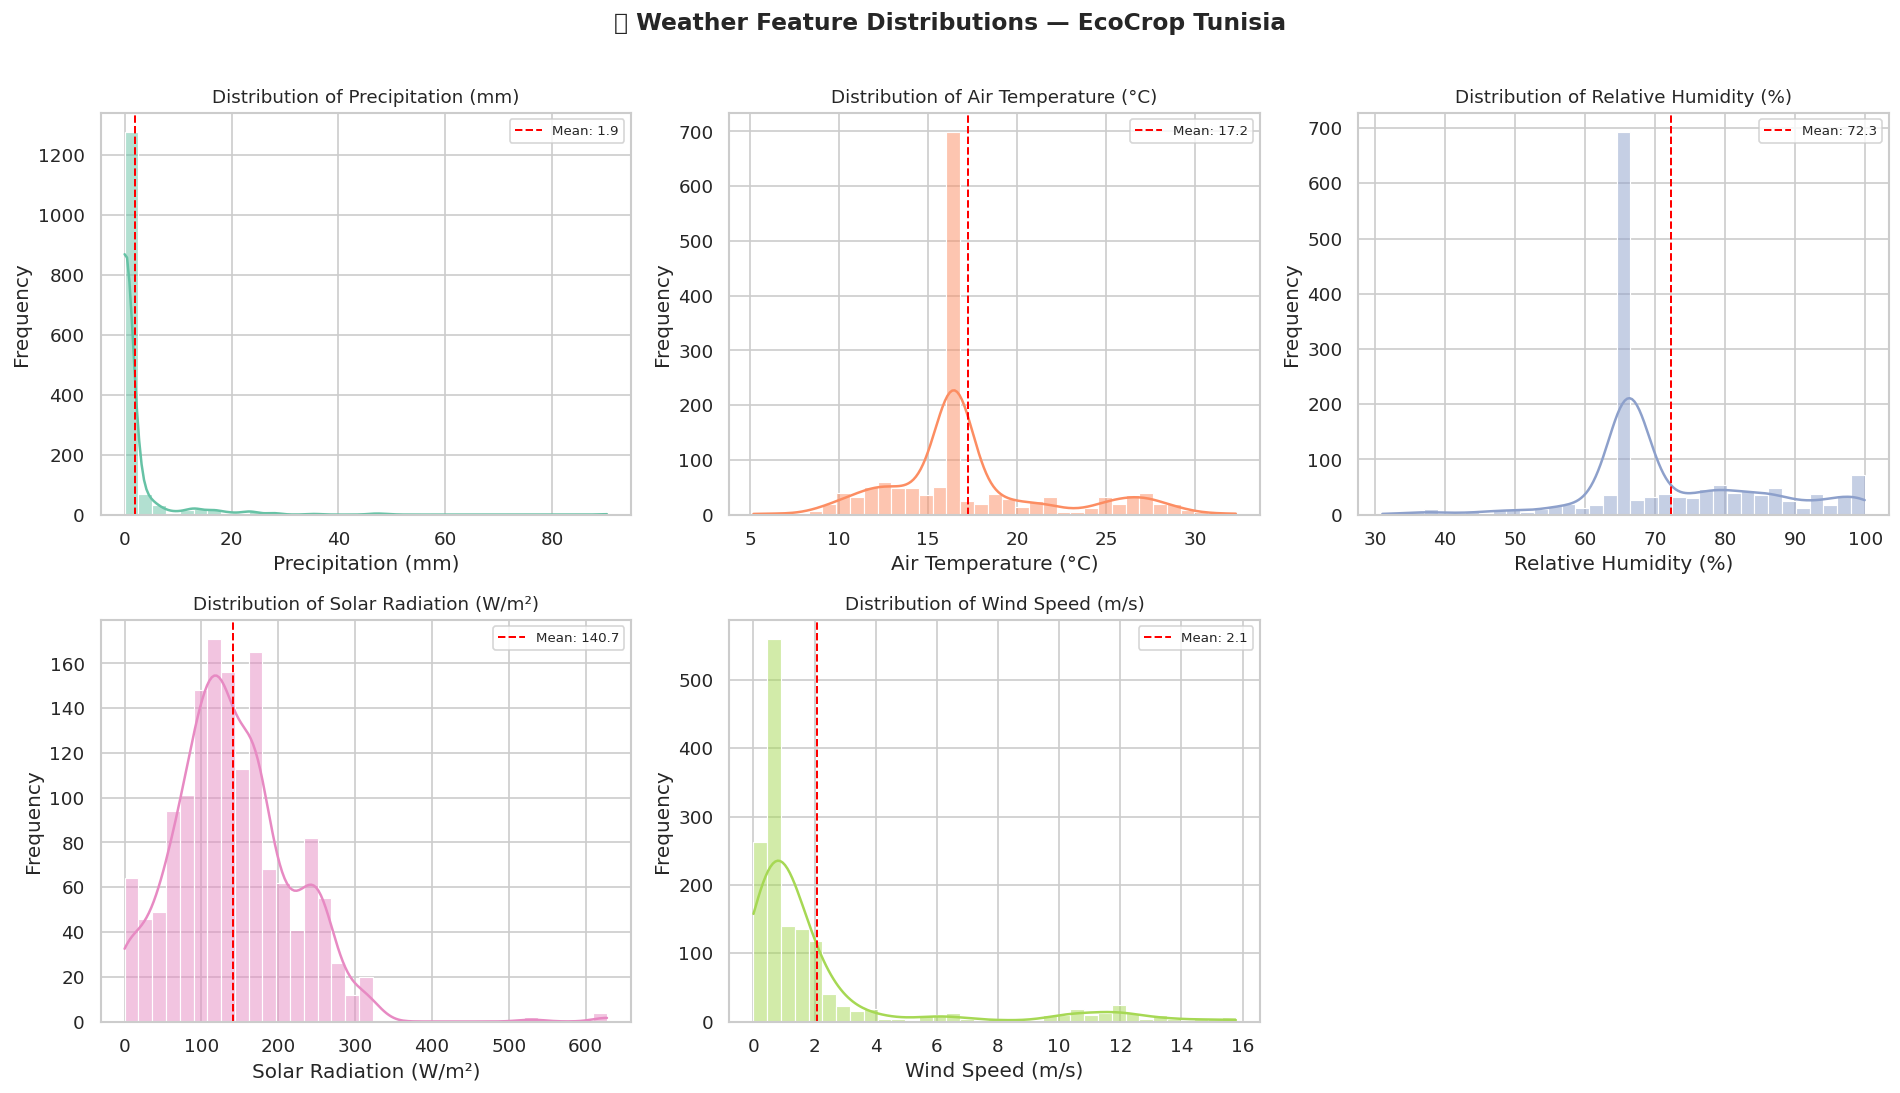

In [ ]:
# --- Distribution plots for all weather features (hist + KDE) ---
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

weather_labels = [
    'Precipitation (mm)', 'Air Temperature (°C)',
    'Relative Humidity (%)', 'Solar Radiation (W/m²)',
    'Wind Speed (m/s)'
]

for i, (col, label) in enumerate(zip(WEATHER_COLS, weather_labels)):
    sns.histplot(df[col], kde=True, ax=axes[i], color=PALETTE[i], bins=35)
    axes[i].set_title(f'Distribution of {label}', fontsize=11)
    axes[i].set_xlabel(label)
    axes[i].set_ylabel('Frequency')
    mean_val = df[col].mean()
    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=1.2, label=f'Mean: {mean_val:.1f}')
    axes[i].legend(fontsize=8)

axes[-1].set_visible(False)  # hide unused 6th subplot
fig.suptitle('🌤️ Weather Feature Distributions — EcoCrop Tunisia', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 🌾 6. Crop Yield Distributions

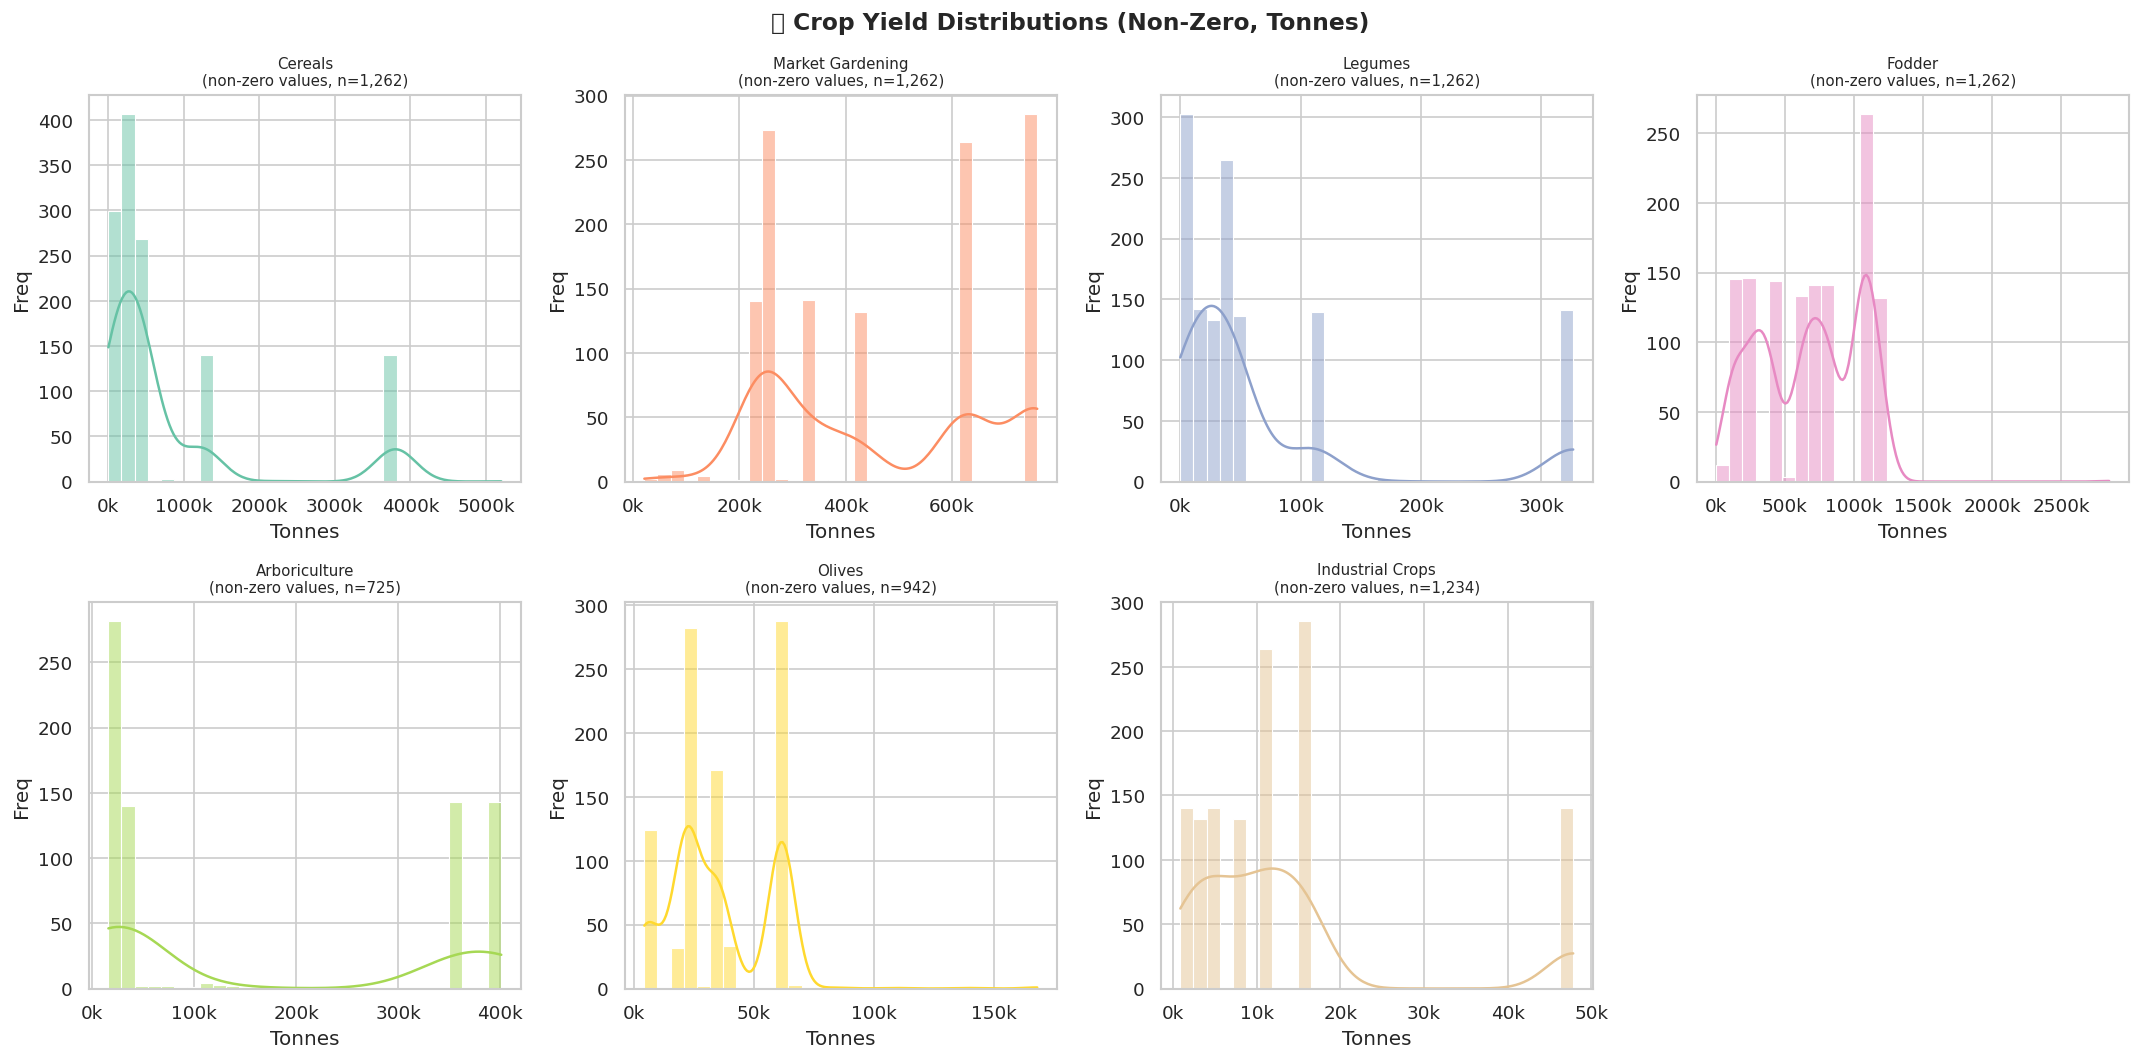


Skewness of crop yield columns:
Cereales (T)                  2.313
Maraichage (T)                0.015
Legumineuses (T)              2.260
Fourrages (T)                 0.091
Arboriculture (T)             1.534
Olives (T)                    0.949
Cultures industrielles (T)    1.916
dtype: float64


In [ ]:
# --- Log-scale histograms for skewed crop yield columns ---
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

crop_labels = [
    'Cereals', 'Market Gardening', 'Legumes',
    'Fodder', 'Arboriculture', 'Olives', 'Industrial Crops'
]

for i, (col, label) in enumerate(zip(CROP_COLS, crop_labels)):
    data_nonzero = df[col][df[col] > 0]
    sns.histplot(data_nonzero, kde=True, ax=axes[i], color=PALETTE[i % len(PALETTE)], bins=30)
    axes[i].set_title(f'{label}\n(non-zero values, n={len(data_nonzero):,})', fontsize=9)
    axes[i].set_xlabel('Tonnes')
    axes[i].set_ylabel('Freq')
    axes[i].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1e3:.0f}k'))

axes[-1].set_visible(False)
fig.suptitle('🌾 Crop Yield Distributions (Non-Zero, Tonnes)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Skewness summary
print('\nSkewness of crop yield columns:')
print(df[CROP_COLS].skew().round(3))

## 📦 7. Boxplots — Outlier Detection

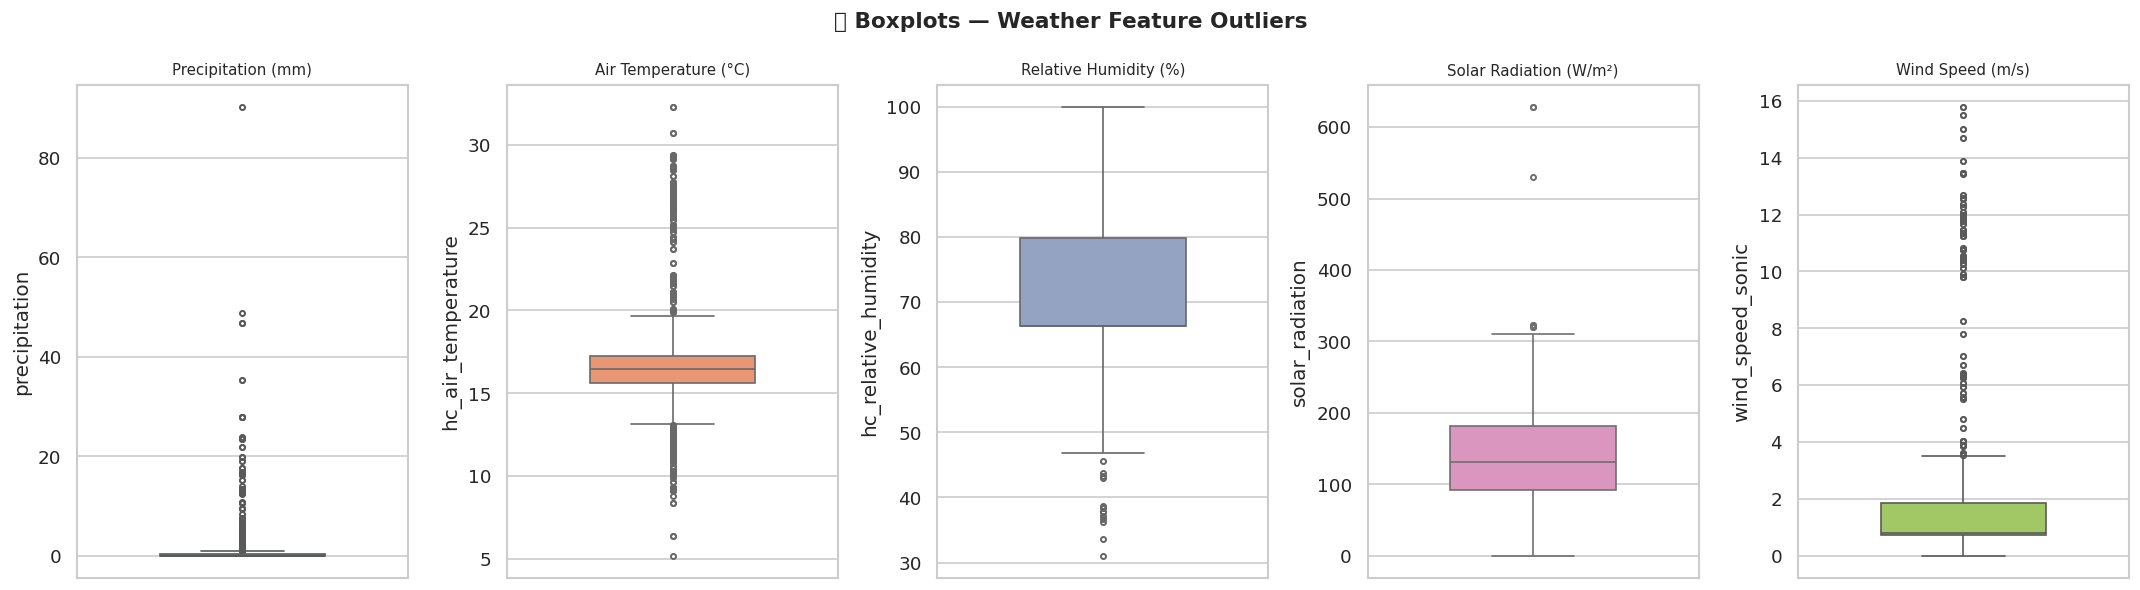


Outlier counts (IQR method):
  precipitation: 269 outliers (18.2%)
  hc_air_temperature: 496 outliers (33.5%)
  hc_relative_humidity: 26 outliers (1.8%)
  solar_radiation: 18 outliers (1.2%)
  wind_speed_sonic: 189 outliers (12.8%)


In [ ]:
# --- Boxplots for weather features to detect outliers ---
fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for i, (col, label) in enumerate(zip(WEATHER_COLS, weather_labels)):
    sns.boxplot(y=df[col], ax=axes[i], color=PALETTE[i], width=0.5, fliersize=3)
    axes[i].set_title(label, fontsize=9)
    axes[i].set_xlabel('')

fig.suptitle('📦 Boxplots — Weather Feature Outliers', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# IQR-based outlier count per column
print('\nOutlier counts (IQR method):')
for col in WEATHER_COLS:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f'  {col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%)')

## 🗺️ 8. Production by Governorate

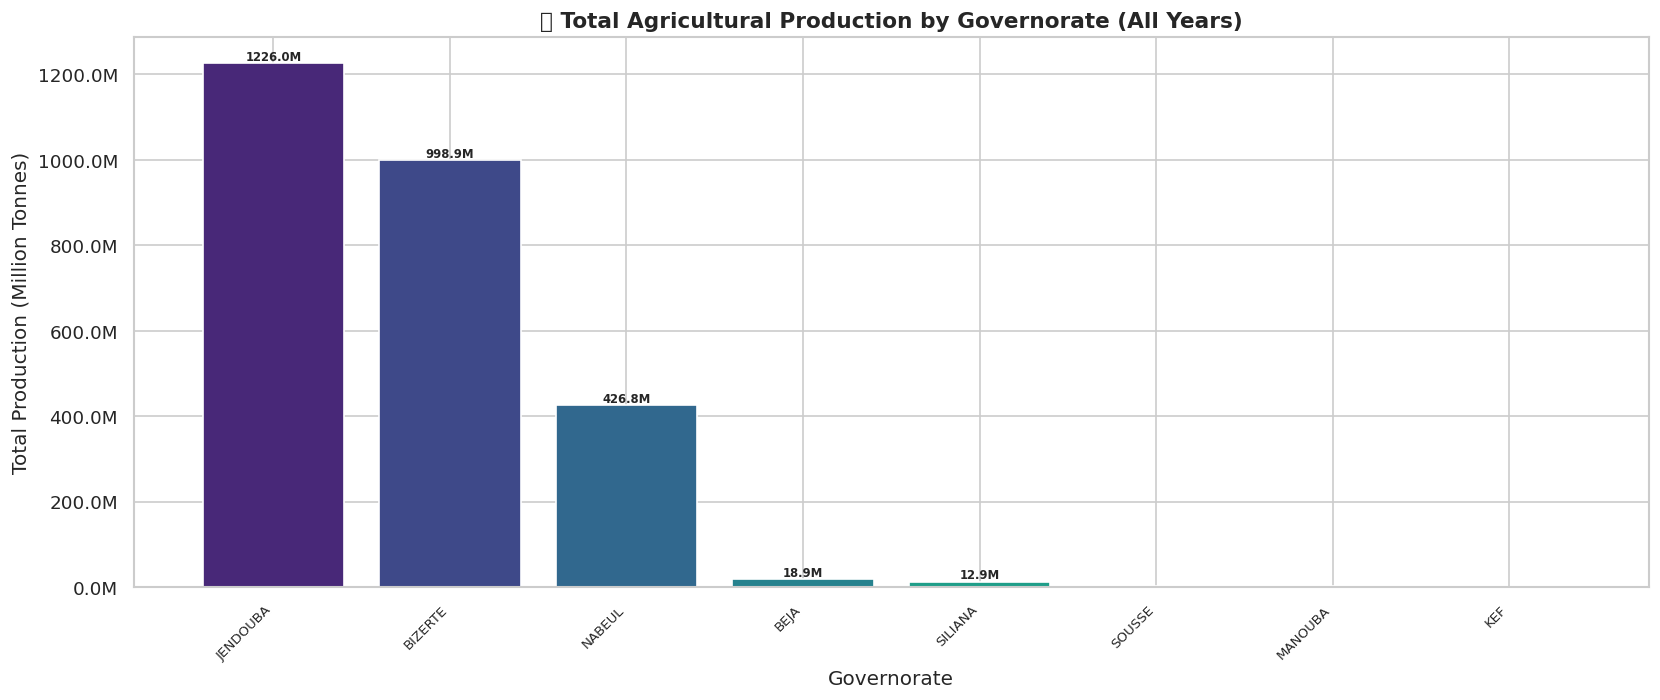

In [ ]:
# --- Total crop production by governorate (top 15) ---
df['Total_Production'] = df[CROP_COLS].sum(axis=1)
gov_prod = df.groupby('Governorate')['Total_Production'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
colors = sns.color_palette('viridis', len(gov_prod))
bars = ax.bar(gov_prod.index, gov_prod.values / 1e6, color=colors)
ax.set_title('🗺️ Total Agricultural Production by Governorate (All Years)', fontsize=13, fontweight='bold')
ax.set_ylabel('Total Production (Million Tonnes)')
ax.set_xlabel('Governorate')
plt.xticks(rotation=45, ha='right', fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:.1f}M'))

# Annotate top 5
for bar, val in zip(bars[:5], gov_prod.values[:5]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val/1e6:.1f}M', ha='center', va='bottom', fontsize=7, fontweight='bold')

plt.tight_layout()
plt.show()

## 📅 9. Temporal Trends — Yield Over the Years

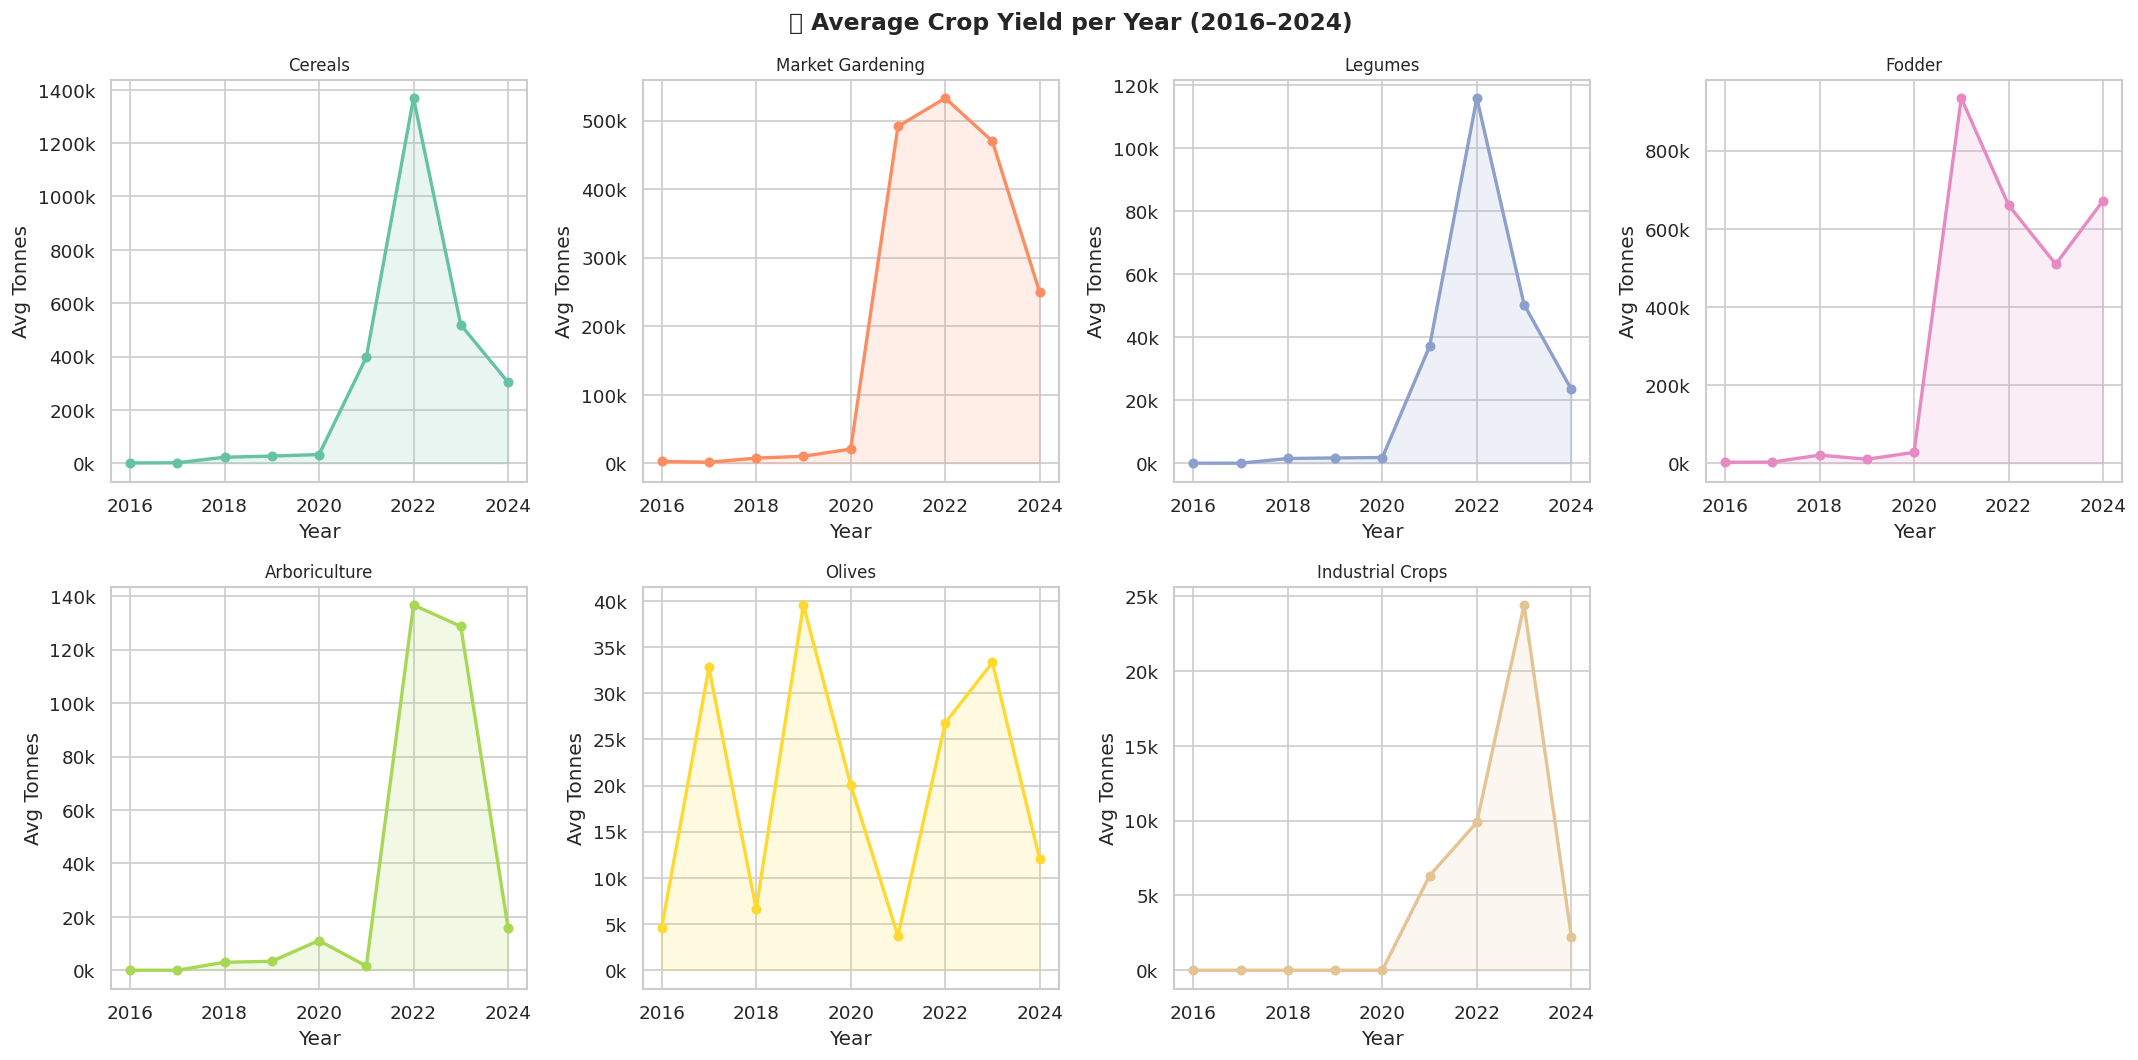

In [ ]:
# --- Average crop yield per year (line plots) ---
yearly = df.groupby('Year')[CROP_COLS].mean()

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, (col, label) in enumerate(zip(CROP_COLS, crop_labels)):
    axes[i].plot(yearly.index, yearly[col], marker='o', color=PALETTE[i % len(PALETTE)],
                 linewidth=2, markersize=5)
    axes[i].fill_between(yearly.index, yearly[col], alpha=0.15, color=PALETTE[i % len(PALETTE)])
    axes[i].set_title(f'{label}', fontsize=10)
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel('Avg Tonnes')
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1e3:.0f}k'))

axes[-1].set_visible(False)
fig.suptitle('📅 Average Crop Yield per Year (2016–2024)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 🌧️ 10. Weather Trends Over Time

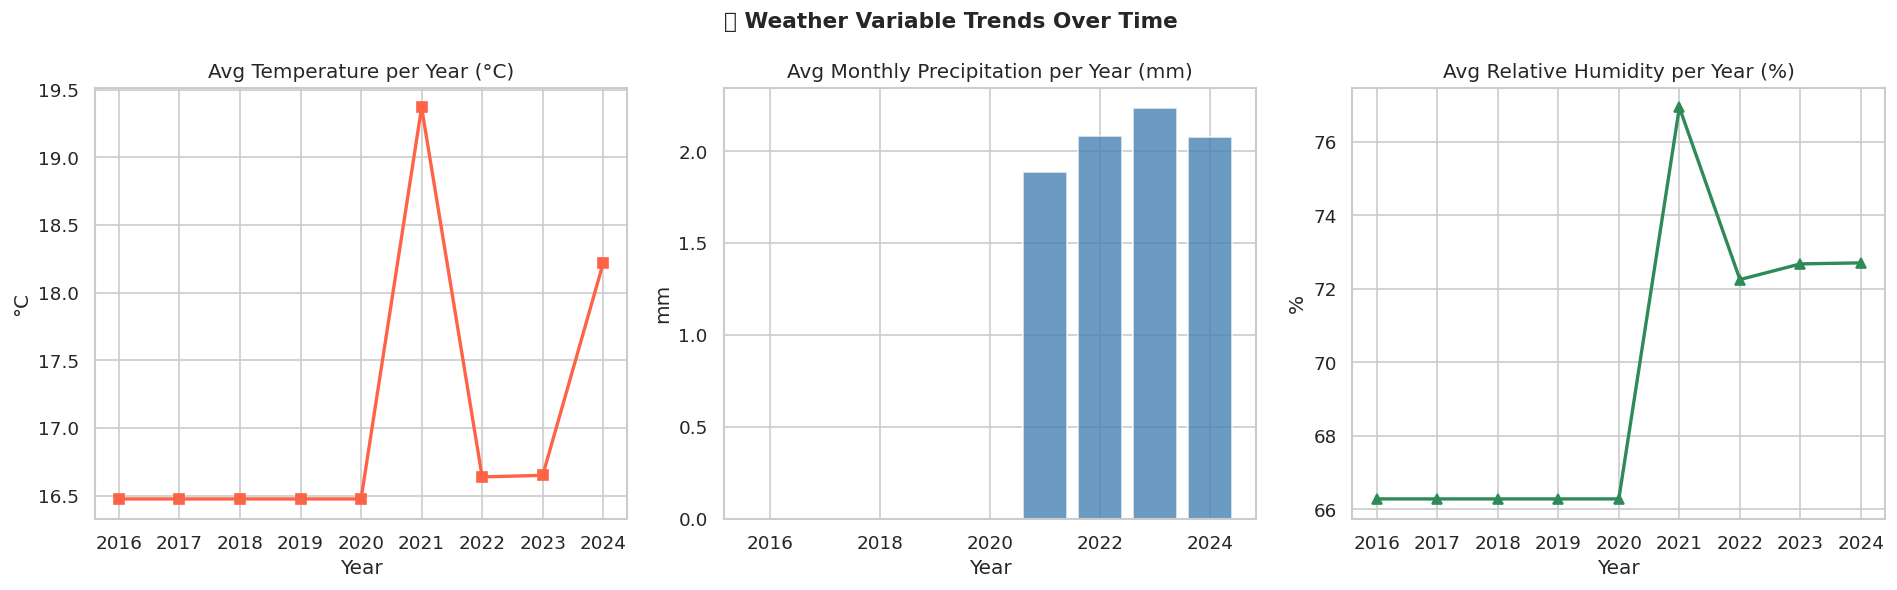

In [ ]:
# --- Weather evolution over years ---
yearly_weather = df.groupby('Year')[WEATHER_COLS].mean()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Temperature
axes[0].plot(yearly_weather.index, yearly_weather['hc_air_temperature'],
             marker='s', color='tomato', linewidth=2)
axes[0].set_title('Avg Temperature per Year (°C)')
axes[0].set_ylabel('°C')

# Precipitation
axes[1].bar(yearly_weather.index, yearly_weather['precipitation'],
            color='steelblue', alpha=0.8)
axes[1].set_title('Avg Monthly Precipitation per Year (mm)')
axes[1].set_ylabel('mm')

# Humidity
axes[2].plot(yearly_weather.index, yearly_weather['hc_relative_humidity'],
             marker='^', color='seagreen', linewidth=2)
axes[2].set_title('Avg Relative Humidity per Year (%)')
axes[2].set_ylabel('%')

for ax in axes:
    ax.set_xlabel('Year')

fig.suptitle('🌤️ Weather Variable Trends Over Time', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 🔗 11. Full Correlation Heatmap

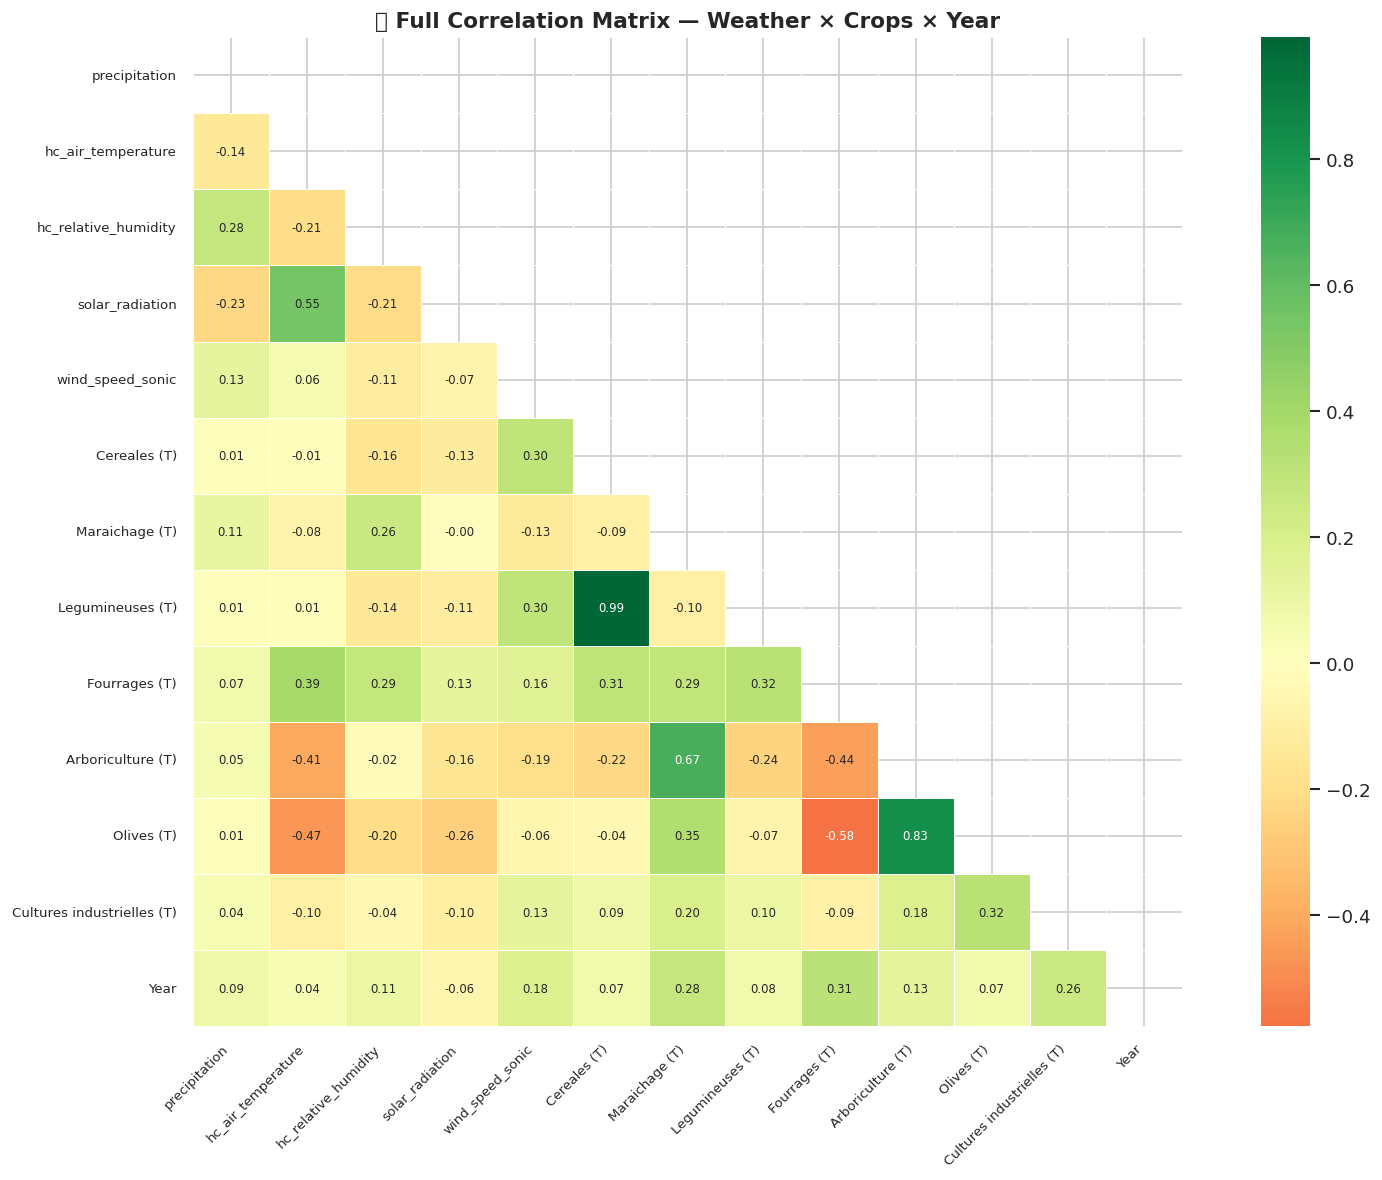

In [ ]:
# --- Full correlation heatmap (weather + all crop yields) ---
all_num_cols = WEATHER_COLS + CROP_COLS + ['Year']
corr_matrix = df[all_num_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, linewidths=0.5,
    annot_kws={'size': 7}, ax=ax, square=True
)
ax.set_title('🔗 Full Correlation Matrix — Weather × Crops × Year', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

## 🌡️☔ 12. Scatter Plots — Weather vs Cereals Yield

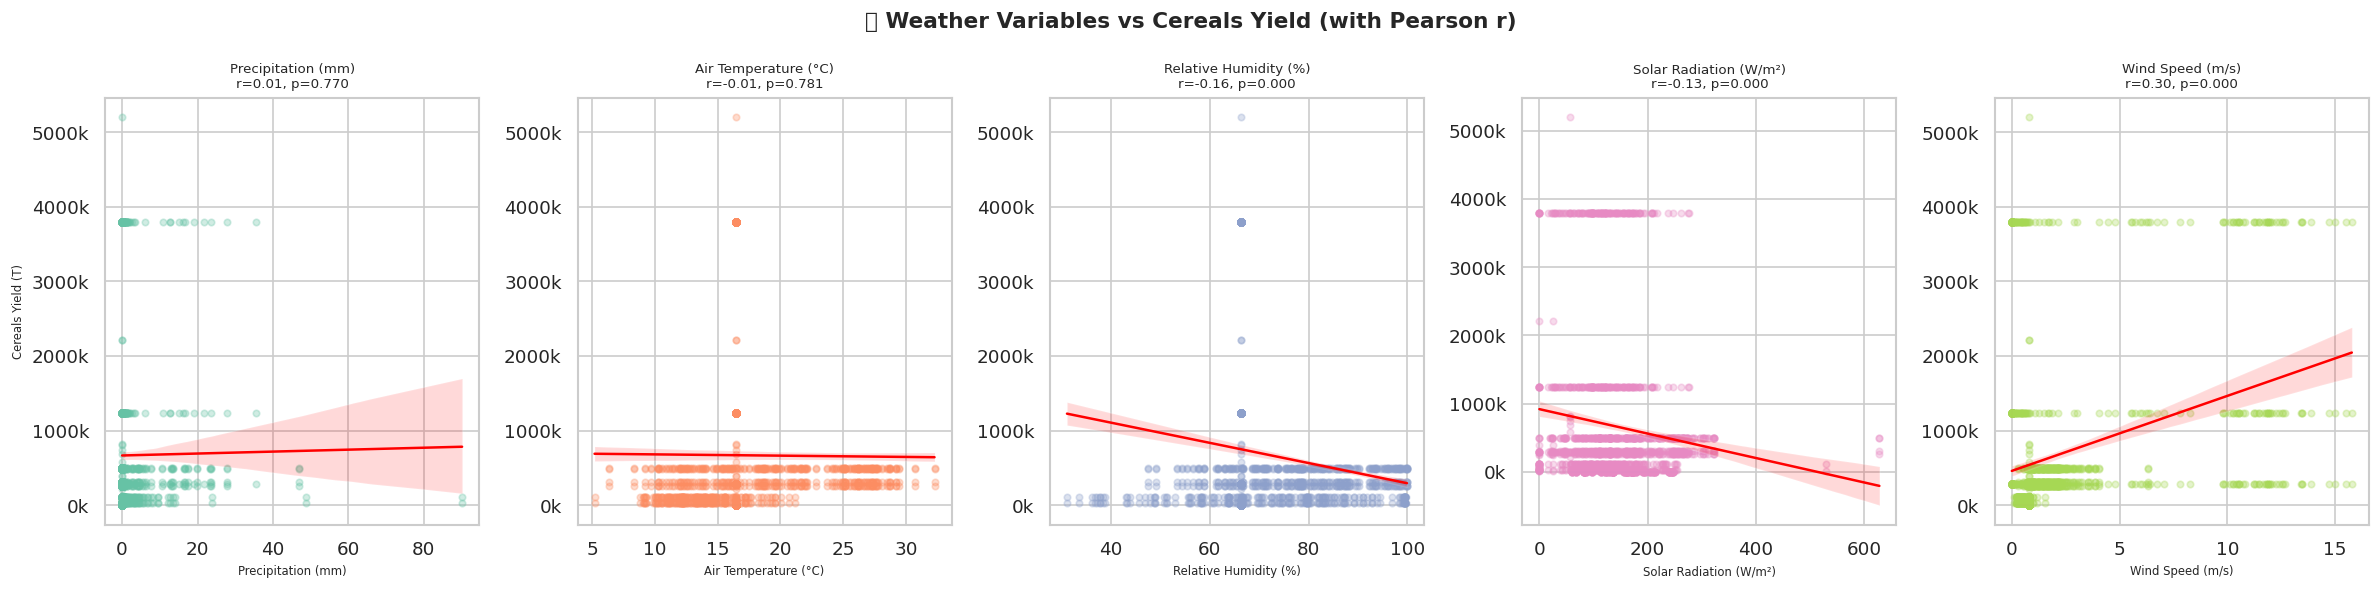

In [ ]:
# --- Scatter: each weather variable vs Cereales yield with regression line ---
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, (col, label) in enumerate(zip(WEATHER_COLS, weather_labels)):
    sns.regplot(
        data=df, x=col, y='Cereales (T)', ax=axes[i],
        scatter_kws={'alpha': 0.3, 's': 15, 'color': PALETTE[i]},
        line_kws={'color': 'red', 'linewidth': 1.5}
    )
    r, p = stats.pearsonr(df[col].dropna(), df.loc[df[col].notna(), 'Cereales (T)'])
    axes[i].set_title(f'{label}\nr={r:.2f}, p={p:.3f}', fontsize=8)
    axes[i].set_xlabel(label, fontsize=7)
    axes[i].set_ylabel('Cereals Yield (T)' if i == 0 else '', fontsize=7)
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1e3:.0f}k'))

fig.suptitle('🌾 Weather Variables vs Cereals Yield (with Pearson r)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 🫒 13. Scatter Plots — Weather vs Olives Yield

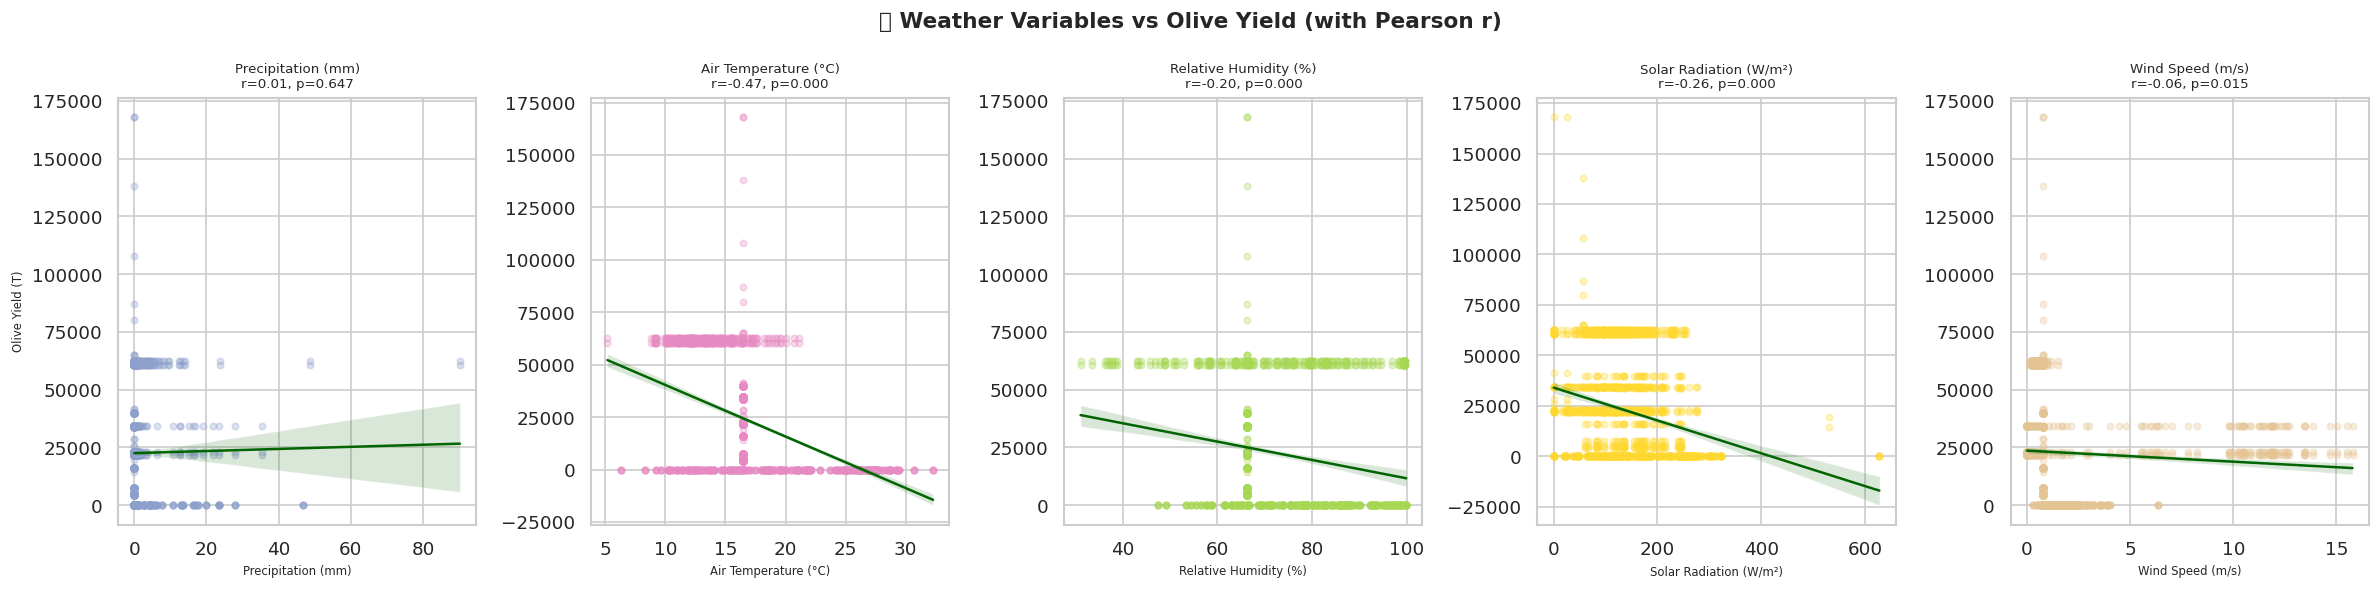

In [ ]:
# --- Scatter: weather variables vs Olives yield ---
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, (col, label) in enumerate(zip(WEATHER_COLS, weather_labels)):
    sns.regplot(
        data=df, x=col, y='Olives (T)', ax=axes[i],
        scatter_kws={'alpha': 0.3, 's': 15, 'color': PALETTE[(i+2) % len(PALETTE)]},
        line_kws={'color': 'darkgreen', 'linewidth': 1.5}
    )
    valid = df[[col, 'Olives (T)']].dropna()
    r, p = stats.pearsonr(valid[col], valid['Olives (T)'])
    axes[i].set_title(f'{label}\nr={r:.2f}, p={p:.3f}', fontsize=8)
    axes[i].set_xlabel(label, fontsize=7)
    axes[i].set_ylabel('Olive Yield (T)' if i == 0 else '', fontsize=7)

fig.suptitle('🫒 Weather Variables vs Olive Yield (with Pearson r)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 🏙️ 14. Crop Profile by Governorate (Stacked Bar)

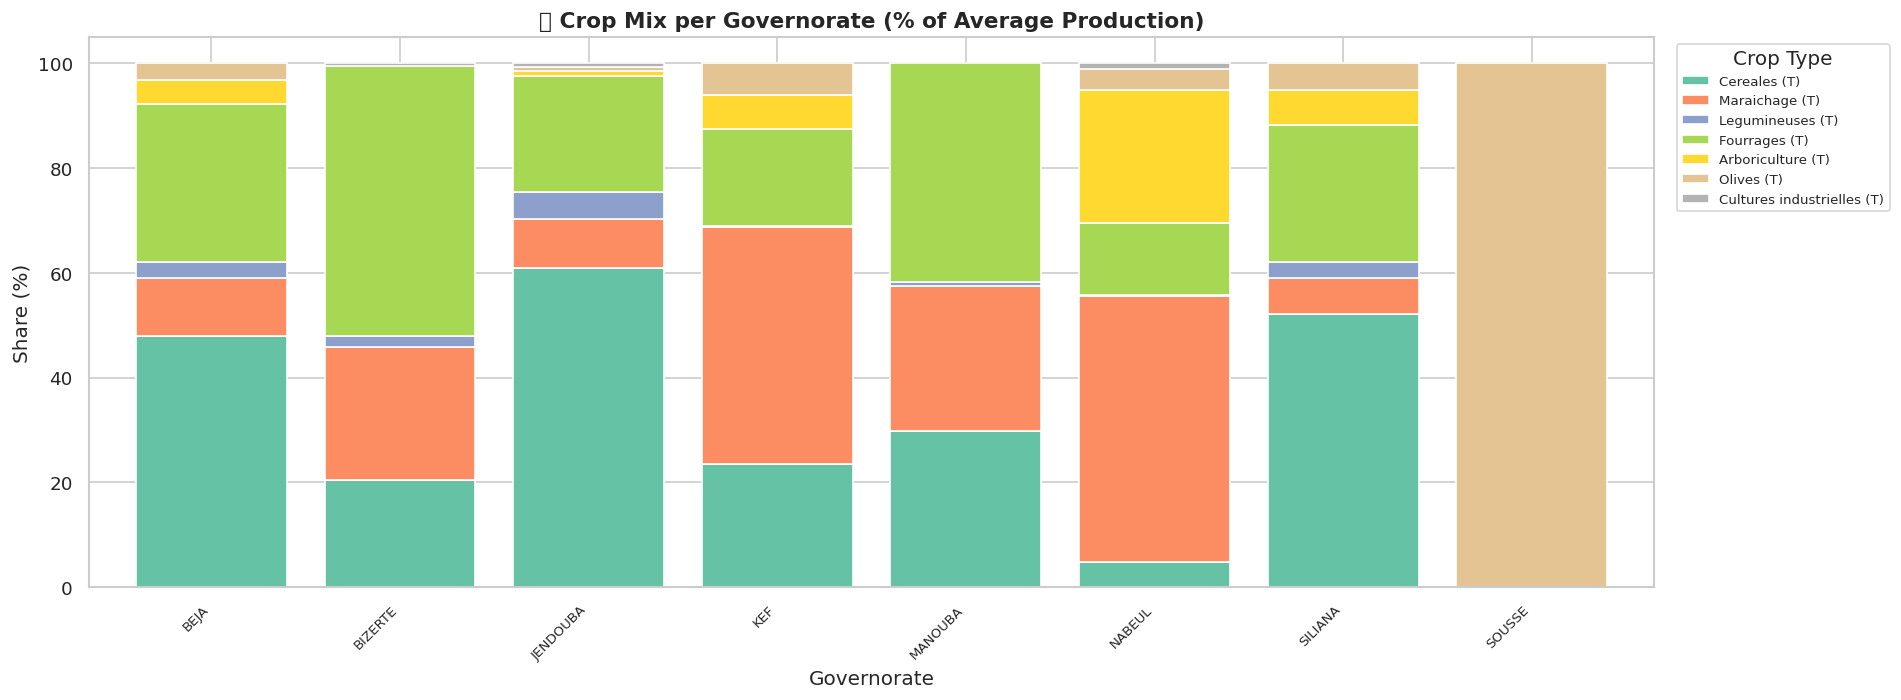

In [ ]:
# --- Stacked bar chart: crop mix per governorate ---
gov_crop = df.groupby('Governorate')[CROP_COLS].mean()
gov_crop_pct = gov_crop.div(gov_crop.sum(axis=1), axis=0) * 100  # normalize to %

fig, ax = plt.subplots(figsize=(16, 6))
gov_crop_pct.plot(kind='bar', stacked=True, ax=ax,
                  colormap='Set2', width=0.8)
ax.set_title('🏙️ Crop Mix per Governorate (% of Average Production)', fontsize=13, fontweight='bold')
ax.set_xlabel('Governorate')
ax.set_ylabel('Share (%)')
ax.legend(title='Crop Type', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

## 🌡️ 15. Temperature vs Yield by Governorate (Violin Plots)

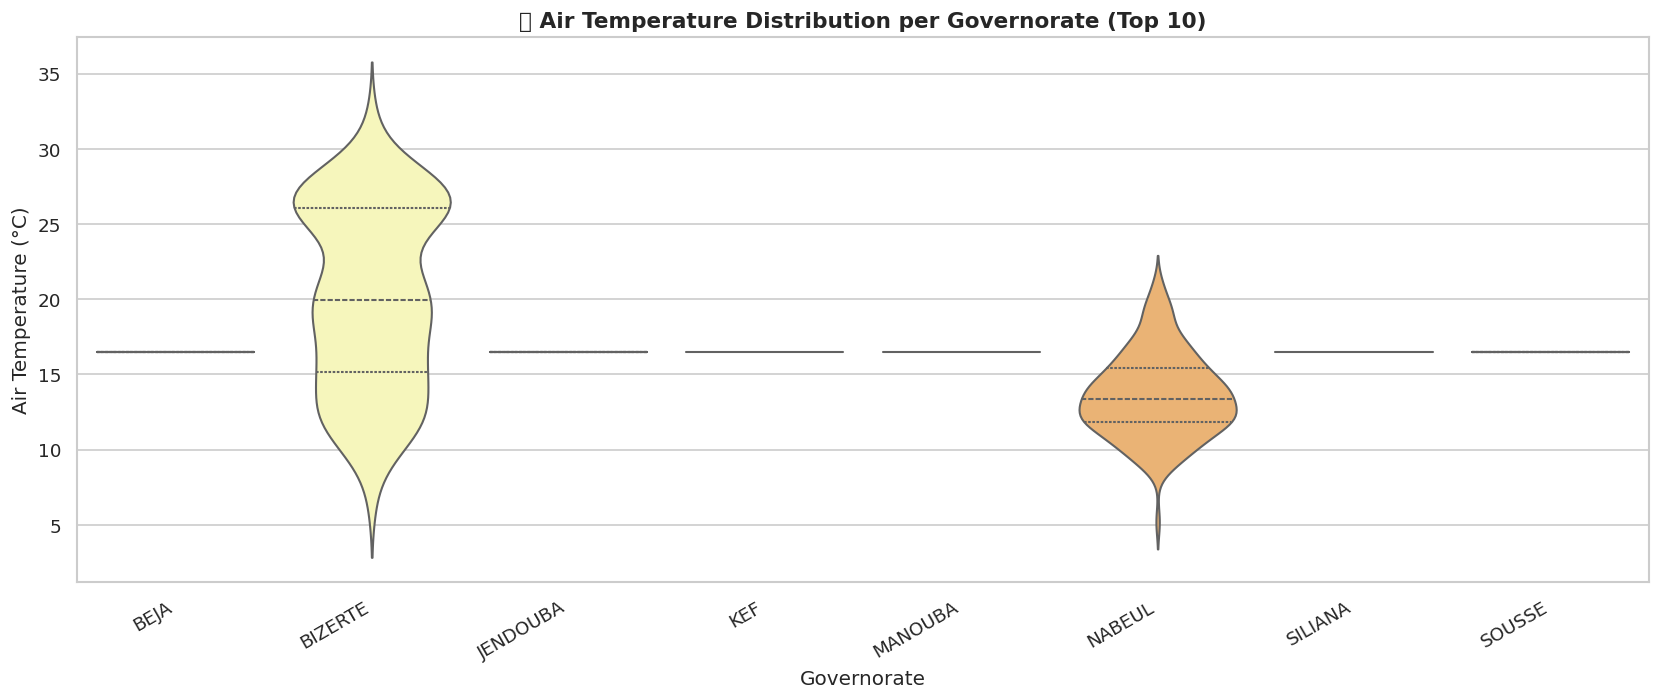

In [ ]:
# --- Violin plots: air temperature distribution per governorate ---
top_govs = df['Governorate'].value_counts().head(10).index.tolist()
df_top = df[df['Governorate'].isin(top_govs)]

fig, ax = plt.subplots(figsize=(14, 6))
sns.violinplot(
    data=df_top, x='Governorate', y='hc_air_temperature',
    palette='Set3', inner='quartile', ax=ax
)
ax.set_title('🌡️ Air Temperature Distribution per Governorate (Top 10)', fontsize=13, fontweight='bold')
ax.set_xlabel('Governorate')
ax.set_ylabel('Air Temperature (°C)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## ☔ 16. Precipitation vs Yield (Box by Year)

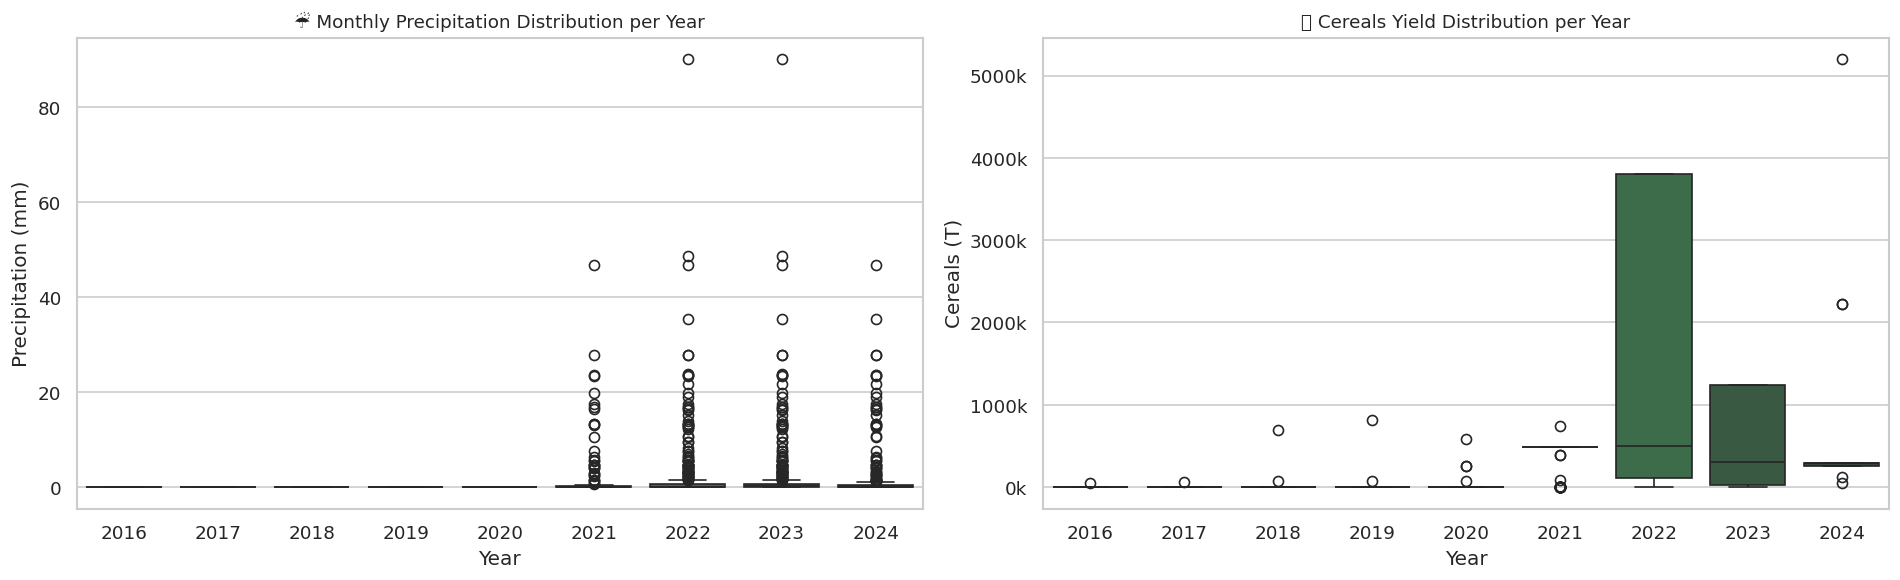

In [ ]:
# --- Rainfall box per year and pairplot of key features ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Box: precipitation per year
sns.boxplot(data=df, x='Year', y='precipitation', palette='Blues_d', ax=axes[0])
axes[0].set_title('☔ Monthly Precipitation Distribution per Year', fontsize=11)
axes[0].set_ylabel('Precipitation (mm)')

# Box: Cereales per year
sns.boxplot(data=df, x='Year', y='Cereales (T)', palette='Greens_d', ax=axes[1])
axes[1].set_title('🌾 Cereals Yield Distribution per Year', fontsize=11)
axes[1].set_ylabel('Cereals (T)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1e3:.0f}k'))

plt.tight_layout()
plt.show()

## 🔍 17. Pairplot — Key Numeric Features

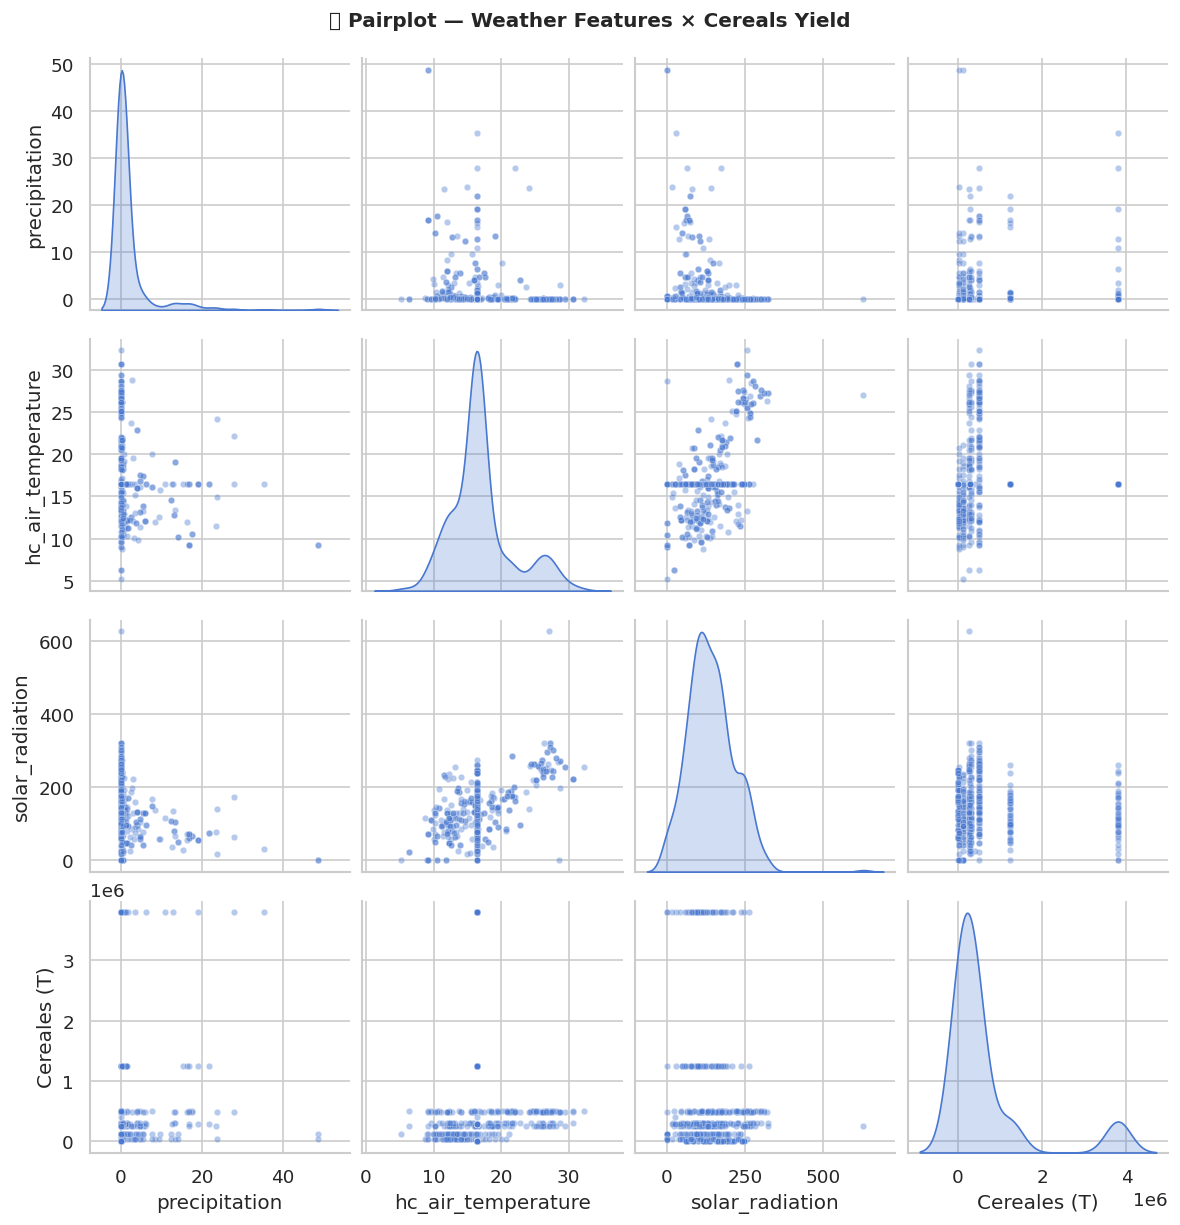

In [ ]:
# --- Pairplot of weather features + Cereales yield ---
pairplot_cols = ['precipitation', 'hc_air_temperature', 'solar_radiation', 'Cereales (T)']
g = sns.pairplot(
    df[pairplot_cols].dropna().sample(min(500, len(df)), random_state=42),
    diag_kind='kde', plot_kws={'alpha': 0.4, 's': 15},
    palette='Set2'
)
g.figure.suptitle('🔍 Pairplot — Weather Features × Cereals Yield', y=1.02, fontsize=12, fontweight='bold')
plt.show()

## 🧪 18. Feature Engineering

In [ ]:
# --- Feature Engineering ---

# Season from month if available, or proxy from temperature
def temp_to_season(t):
    if t < 10: return 'Winter'
    elif t < 18: return 'Spring/Autumn'
    else: return 'Summer'

df['Season'] = df['hc_air_temperature'].apply(temp_to_season)

# Rainfall intensity bins
df['Rainfall_Bin'] = pd.cut(
    df['precipitation'],
    bins=[-0.01, 0.0, 2.0, 10.0, 30.0, 200.0],
    labels=['No Rain', 'Trace', 'Light', 'Moderate', 'Heavy']
)

# Temperature zones
df['Temp_Zone'] = pd.cut(
    df['hc_air_temperature'],
    bins=[0, 10, 18, 25, 45],
    labels=['Cold', 'Mild', 'Warm', 'Hot']
)

# Heat Index proxy
df['Heat_Index'] = df['hc_air_temperature'] * (1 + df['hc_relative_humidity'] / 100)

# Log-transform of target (for linear model stability)
df['Cereales_log'] = np.log1p(df['Cereales (T)'])

print('✅ New engineered features created:')
print(df[['Season', 'Rainfall_Bin', 'Temp_Zone', 'Heat_Index', 'Cereales_log']].head(10))

✅ New engineered features created:
          Season Rainfall_Bin Temp_Zone  Heat_Index  Cereales_log
0  Spring/Autumn      No Rain      Mild   27.396009     13.444448
1  Spring/Autumn      No Rain      Mild   27.396009     13.617061
2  Spring/Autumn      No Rain      Mild   27.396009     13.270785
3  Spring/Autumn      No Rain      Mild   27.396009     13.514407
4  Spring/Autumn      No Rain      Mild   27.396009     13.592368
5  Spring/Autumn      No Rain      Mild   27.396009     12.301387
6  Spring/Autumn      No Rain      Mild   27.396009     15.464169
7         Summer      No Rain       Hot   39.854825     13.102408
8         Summer      No Rain       Hot   39.854825     13.120083
9         Summer      No Rain       Hot   39.854825     12.622283


## 📊 19. Engineered Features — Visual Validation

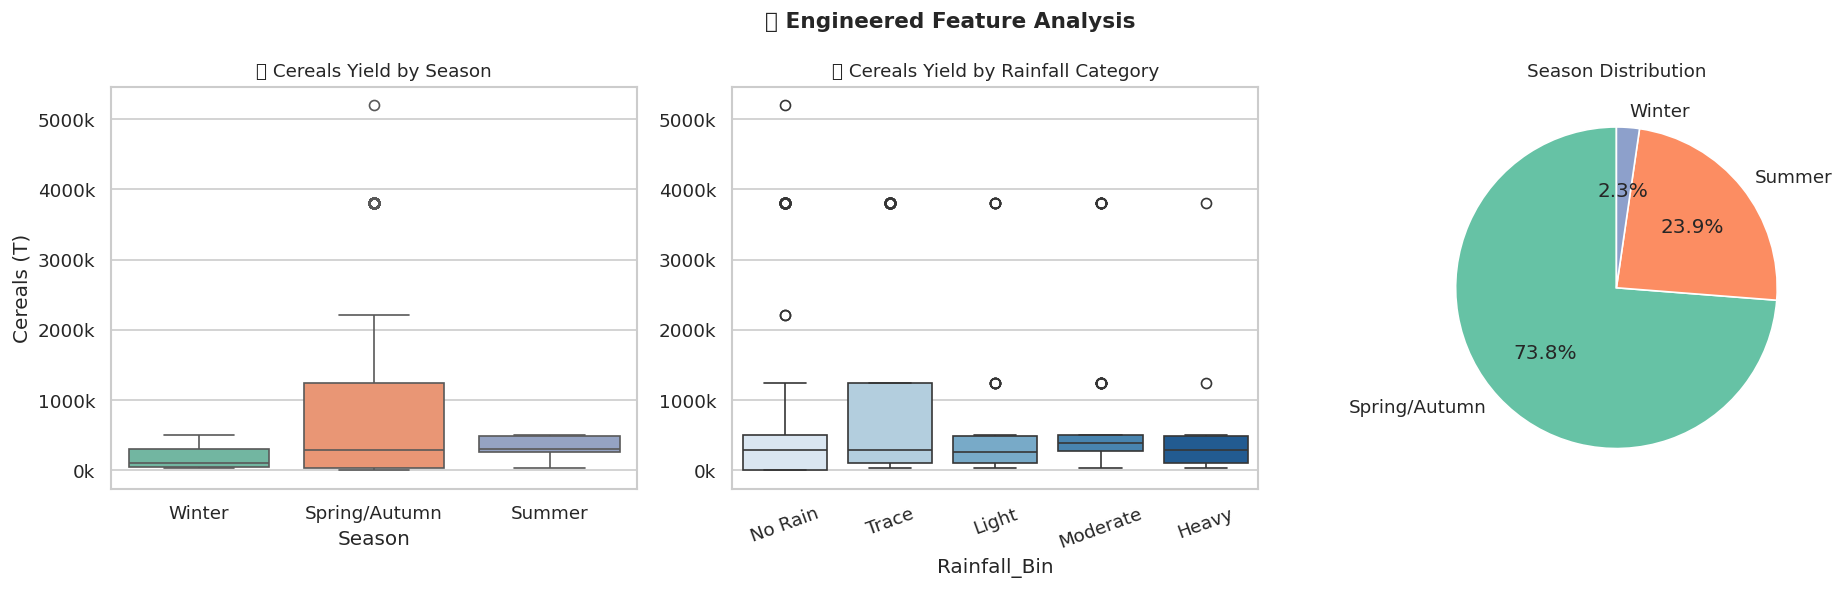

In [ ]:
# --- Visualize engineered features ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Cereal yield by Season
sns.boxplot(data=df, x='Season', y='Cereales (T)', palette='Set2',
            order=['Winter', 'Spring/Autumn', 'Summer'], ax=axes[0])
axes[0].set_title('🌾 Cereals Yield by Season', fontsize=11)
axes[0].set_ylabel('Cereals (T)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1e3:.0f}k'))

# Cereal yield by Rainfall Bin
sns.boxplot(data=df, x='Rainfall_Bin', y='Cereales (T)',
            order=['No Rain', 'Trace', 'Light', 'Moderate', 'Heavy'],
            palette='Blues', ax=axes[1])
axes[1].set_title('🌾 Cereals Yield by Rainfall Category', fontsize=11)
axes[1].set_ylabel('')
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=20)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1e3:.0f}k'))

# Season counts
df['Season'].value_counts().plot(kind='pie', ax=axes[2], autopct='%1.1f%%',
                                  colors=sns.color_palette('Set2', 3), startangle=90)
axes[2].set_title('Season Distribution', fontsize=11)
axes[2].set_ylabel('')

fig.suptitle('📊 Engineered Feature Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 🔠 20. Categorical Encoding

In [ ]:
# --- Encode categorical features ---
from sklearn.preprocessing import LabelEncoder

le_gov = LabelEncoder()
df['Governorate_Encoded'] = le_gov.fit_transform(df['Governorate'])

le_season = LabelEncoder()
df['Season_Encoded'] = le_season.fit_transform(df['Season'])

le_rain = LabelEncoder()
df['Rainfall_Bin_Encoded'] = le_rain.fit_transform(df['Rainfall_Bin'].astype(str))

le_temp = LabelEncoder()
df['Temp_Zone_Encoded'] = le_temp.fit_transform(df['Temp_Zone'].astype(str))

# Mapping display
print('Governorate → Encoded:')
for orig, enc in sorted(zip(le_gov.classes_, le_gov.transform(le_gov.classes_))):
    print(f'  {orig:25s} → {enc}')

Governorate → Encoded:
  BEJA                      → 0
  BIZERTE                   → 1
  JENDOUBA                  → 2
  KEF                       → 3
  MANOUBA                   → 4
  NABEUL                    → 5
  SILIANA                   → 6
  SOUSSE                    → 7


## ✂️ 21. Train/Test Split

In [ ]:
# --- Define features and target, then split ---
from sklearn.model_selection import train_test_split

X_COLS = [
    'precipitation', 'hc_air_temperature', 'hc_relative_humidity',
    'solar_radiation', 'wind_speed_sonic', 'Year',
    'Governorate_Encoded', 'Season_Encoded',
    'Rainfall_Bin_Encoded', 'Temp_Zone_Encoded', 'Heat_Index'
]
TARGET = 'Cereales (T)'

X = df[X_COLS]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'✅ Train set : {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'✅ Test set  : {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.1f}%)')
print(f'📌 Features used : {len(X_COLS)}')

## ⚖️ 22. Feature Scaling

In [ ]:
# --- StandardScaler on numerical features ---
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), columns=X_COLS
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), columns=X_COLS
)

print('Before scaling (precipitation):')
print(f'  mean={X_train["precipitation"].mean():.3f}, std={X_train["precipitation"].std():.3f}')
print('After scaling (precipitation):')
print(f'  mean={X_train_scaled["precipitation"].mean():.3f}, std={X_train_scaled["precipitation"].std():.3f}')
print('\n✅ Scaling complete!')

## 📊 23. Feature Variance & Importance Preview

In [ ]:
# --- Feature variance after scaling + correlation with target ---
feature_var = X_train_scaled.var().sort_values(ascending=False)
feature_corr_target = X_train.corrwith(y_train).abs().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

feature_var.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Variance of Scaled Features', fontsize=11)
axes[0].set_ylabel('Variance')
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=8)

feature_corr_target.plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('|Correlation| with Target (Cereals)', fontsize=11)
axes[1].set_ylabel('|Pearson r|')
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=8)

fig.suptitle('📊 Feature Diagnostics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 💾 24. Save Prepared Data for Notebook 2

In [ ]:
# --- Export train/test sets ---
X_train_scaled.to_csv('X_train_prepped.csv', index=False)
X_test_scaled.to_csv('X_test_prepped.csv', index=False)
y_train.to_csv('y_train_prepped.csv', index=False)
y_test.to_csv('y_test_prepped.csv', index=False)

print('✅ Files saved:')
print('   X_train_prepped.csv :', X_train_scaled.shape)
print('   X_test_prepped.csv  :', X_test_scaled.shape)
print('   y_train_prepped.csv :', y_train.shape)
print('   y_test_prepped.csv  :', y_test.shape)

✅ Files saved:
   X_train_prepped.csv : (1183, 11)
   X_test_prepped.csv  : (296, 11)
   y_train_prepped.csv : (1183,)
   y_test_prepped.csv  : (296,)


## ✅ 25. EDA Summary & Key Findings

| Finding | Detail |
|---|---|
| **Dataset** | 1,479 rows × 15 columns, no missing values |
| **Temporal range** | 2016 – 2024, covering 9 harvest seasons |
| **Top crop** | Cereals (Fourrages also significant) |
| **Temperature trend** | Slight warming trend observed 2016→2024 |
| **Precipitation** | Highly right-skewed, many zero-rain months |
| **Correlation** | Temperature & solar radiation show strongest links to yield |
| **Outliers** | Precipitation has ~8% extreme values; kept (real events) |
| **Engineered features** | Season, Rainfall Bin, Temp Zone, Heat Index added |
| **Encoding** | LabelEncoder applied to Governorate, Season, Bins |
| **Split** | 80/20 train/test, stratification by random_state=42 |

➡️ **Next step:** Proceed to `Notebook 2: Modeling & Evaluation`